In [1]:
# Setup — run this first!
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

# Notebook display settings
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 12
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
np.random.seed(42)

print("All libraries loaded!")
print(f"NumPy version : {np.__version__}")
import scipy; print(f"SciPy version : {scipy.__version__}")
print(f"Pandas version: {pd.__version__}")


All libraries loaded!
NumPy version : 2.3.5
SciPy version : 1.16.3
Pandas version: 2.3.3


In [2]:
# Load the tips dataset — our companion for today
tips = sns.load_dataset("tips")

print("Dataset shape:", tips.shape)
print("\nFirst 5 rows:")
print(tips.head().to_string())
print("\nColumn types:")
print(tips.dtypes)
print("\nQuick stats:")
print(tips.describe().round(2).to_string())

Dataset shape: (244, 7)

First 5 rows:
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4

Column types:
total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

Quick stats:
       total_bill     tip    size
count      244.00  244.00  244.00
mean        19.79    3.00    2.57
std          8.90    1.38    0.95
min          3.07    1.00    1.00
25%         13.35    2.00    2.00
50%         17.80    2.90    2.00
75%         24.13    3.56    3.00
max         50.81   10.00    6.00


In [ ]:
# Exercise 1 — Your First SciPy Stats Call
# Task: describe the tip column using scipy.stats

tip_data = tips["tip"].values

# 1. Use stats.describe() — it returns a named tuple
desc = stats.describe(tip_data)
print(f"Count  : {desc.nobs}")
print(f"Min/Max: {desc.minmax}")
print(f"Mean   : {desc.mean:.4f}")
print(f"Variance: {desc.variance:.4f}")

# 2. Skewness
sk = stats.skew(tip_data)
print(f"Skewness : {sk:.4f}")

# 3. Kurtosis
kurt = stats.kurtosis(tip_data)
print(f"Kurtosis : {kurt:.4f}")

# 4. Interpretation
print("\nInterpretation:", "___")

total_bill  : skew = +1.126  → right-skewed
tip         : skew = +1.456  → right-skewed
size        : skew = +1.439  → right-skewed


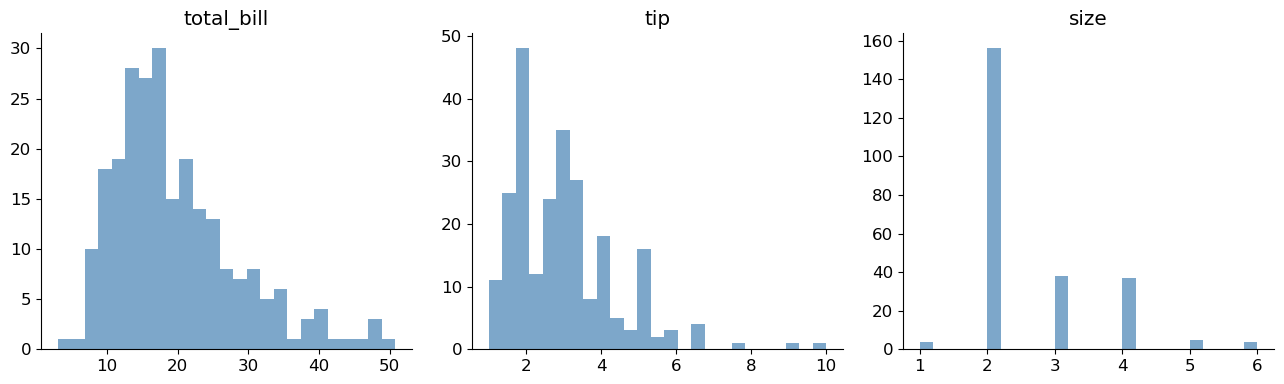

In [6]:
# Exercise 2 — Skewness Diagnosis
cols = ["total_bill", "tip", "size"]

# 1-3. Loop and classify
for col in cols:
    sk = stats.skew(tips[col].values)
    if abs(sk) < 0.5:
        label = "symmetric"
    elif sk > 0:
        label = "right-skewed"
    else:
        label = "left-skewed"
    print(f"{col:12s}: skew = {sk:+.3f}  → {label}")

# 4. Histogram grid
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for i, col in enumerate(cols):
    axes[i].hist(tips[col], bins=25, color="steelblue", alpha=0.7)
    axes[i].set_title(col)
plt.tight_layout(); plt.show()

P(10 <= bill <= 25) = 0.5851 = 58.5%
90th percentile bill = $31.19
Simulated bills: [24.21 18.56 25.55 33.34 17.7 ]


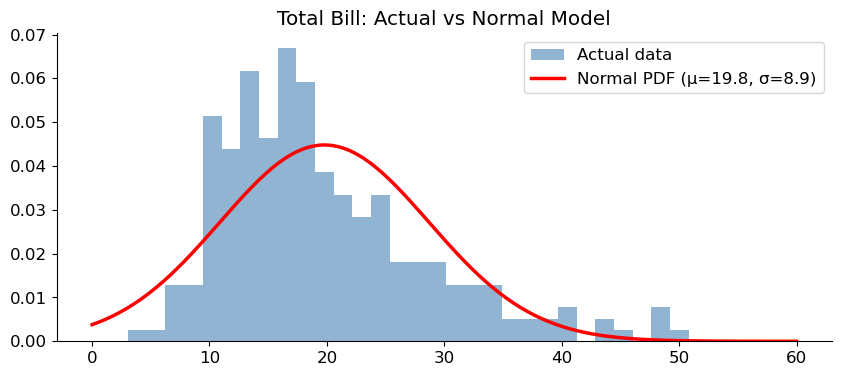

In [7]:
# Exercise 3 — Distribution Questions
mu = tips["total_bill"].mean()
sigma = tips["total_bill"].std()

# 1. P(10 <= bill <= 25)
p_between = stats.norm.cdf(25, mu, sigma) - stats.norm.cdf(10, mu, sigma)
print(f"P(10 <= bill <= 25) = {p_between:.4f} = {p_between*100:.1f}%")

# 2. 90th percentile
# this gives the top 10%. The opposite of CDF. You give it a % and it will give you the numer)
p90 = stats.norm.ppf(0.9, mu, sigma)
print(f"90th percentile bill = ${p90:.2f}")

# 3. Generate 5 simulated bills
sim = stats.norm.rvs(mu, sigma, size=5)
print(f"Simulated bills: {np.round(sim, 2)}")

# 4. Histogram vs PDF
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(tips["total_bill"], bins=30, density=True,
        alpha=0.6, color="steelblue", label="Actual data")
x = np.linspace(0, 60, 200)
ax.plot(x, stats.norm.pdf(x, mu, sigma), "r-", lw=2.5,
        label=f"Normal PDF (μ={mu:.1f}, σ={sigma:.1f})")
ax.set_title("Total Bill: Actual vs Normal Model"); ax.legend(); plt.show()

In [9]:
# Exercise 4 — T-Test: Smokers vs Non-Smokers

# Step 1: State hypotheses
# H0: Smokers and Non-Smokers tip at the same rate
# H1: Smokers and Non-Smokers tip differently

# Step 2: Examine groups
smoker_tips    = tips[tips["smoker"] == "Yes"]["tip"].values
nonsmoker_tips = tips[tips["smoker"] == "No"]["tip"].values
print(f"Smoker   : n={len(smoker_tips)}, mean=${np.mean(smoker_tips):.3f}")
print(f"Non-smoker: n={len(nonsmoker_tips)}, mean=${np.mean(nonsmoker_tips):.3f}")

# Step 3: Run test
t_stat, p_value = stats.ttest_ind(smoker_tips, nonsmoker_tips)
print(f"t = {t_stat:.4f}, p = {p_value:.4f}")

# Step 4 & 5: Decision and conclusion
if p_value < 0.5:
    print("Conclusion: There is a significant difference")
else:
    print("Conclusion: There is no significant difference")

Smoker   : n=93, mean=$3.009
Non-smoker: n=151, mean=$2.992
t = 0.0922, p = 0.9266
Conclusion: There is no significant difference
